# 02 — First ALS run: baseline, and why we log-scale counts

**Milestone 3.** Fit confidence-weighted implicit ALS against the frozen harness and answer one modelling question before any hyperparameter search: **how should listen counts enter the model?**

We compare, on the *search-visible* split (`train.npz` / `test.npz`), against the popularity baseline:
- raw-count confidence `c = 1 + alpha*count`, and
- log-scaled confidence `c = 1 + alpha*log(1+count)`,

across a range of `alpha`. The winner becomes a fixed modelling decision; `alpha`/`factors`/`regularization`/`iterations` are then tuned by the disciplined search in Milestone 4. Everything is scored with `eval_core` (frozen).

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import scipy.sparse as sp
from src import data_loading as dl, als_model, plotting as viz
from src.harness import eval_core
from src.utils import TRAIN_PATH, TEST_PATH, ITEM_INDEX_PATH

viz.set_style()
FIG = project_root / 'outputs' / 'figures'
K = 10

train = sp.load_npz(TRAIN_PATH).tocsr()
test = sp.load_npz(TEST_PATH).tocsr()
scored = np.where(np.asarray((test > 0).sum(axis=1)).ravel() > 0)[0]
n_items = train.shape[1]

def score(recs):
    m = eval_core.evaluate_recommendations(recs, test, scored, K)
    m['coverage'] = len(set(np.asarray(recs).ravel().tolist())) / n_items
    return m

print(f'train {train.nnz:,} | test {test.nnz:,} | scored users {len(scored):,} | items {n_items:,}')

train 59,411 | test 14,854 | scored users 1,883 | items 17,632


## The popularity baseline (the number to beat)

Given the artist long tail (61% of artists have one listener), non-personalised popularity is a genuinely strong, honest reference point.

In [2]:
listeners = np.asarray((train > 0).sum(axis=0)).ravel()
pop_order = np.argsort(listeners)[::-1].tolist()  # python ints: fast set membership

def popularity_topk(train_items: set, k: int = K):
    """Most-listened artists the user lacks in train, best-first (stops at k)."""
    out = []
    for i in pop_order:
        if i not in train_items:
            out.append(i)
            if len(out) == k:
                break
    return out

pop_recs = np.array([popularity_topk(set(train.getrow(u).indices.tolist())) for u in scored])
pop = score(pop_recs)
print(f"POPULARITY  NDCG@{K}={pop[f'ndcg@{K}']:.4f}  P@{K}={pop[f'precision@{K}']:.4f}  "
      f"R@{K}={pop[f'recall@{K}']:.4f}  coverage={pop['coverage']:.3f}")

POPULARITY  NDCG@10=0.0630  P@10=0.0495  R@10=0.0631  coverage=0.001


## The count-transform ablation

Fit ALS (factors=64, reg=0.01, iters=15) with raw vs log1p counts across `alpha`, scoring each on the held-out test set.

In [3]:
alphas = [1, 3, 10, 30, 100]
series, records = {'linear': [], 'log1p': []}, []
for transform in ('linear', 'log1p'):
    for a in alphas:
        model, conf = als_model.train_als(train, factors=64, regularization=0.01,
                                          iterations=15, alpha=a, seed=0,
                                          count_transform=transform)
        recs = als_model.recommend_top_n(model, conf, scored, n=K)
        m = score(recs)
        series[transform].append(m[f'ndcg@{K}'])
        records.append({'transform': transform, 'alpha': a,
                        'ndcg': m[f'ndcg@{K}'], 'coverage': m['coverage']})
        print(f"{transform:<6} a={a:<3} NDCG@{K}={m[f'ndcg@{K}']:.4f}  coverage={m['coverage']:.3f}")

linear a=1   NDCG@10=0.0983  coverage=0.094


linear a=3   NDCG@10=0.0713  coverage=0.089


linear a=10  NDCG@10=0.0505  coverage=0.089


linear a=30  NDCG@10=0.0352  coverage=0.101


linear a=100 NDCG@10=0.0237  coverage=0.115


log1p  a=1   NDCG@10=0.1577  coverage=0.056


log1p  a=3   NDCG@10=0.1550  coverage=0.074


log1p  a=10  NDCG@10=0.1393  coverage=0.093


log1p  a=30  NDCG@10=0.1186  coverage=0.101


log1p  a=100 NDCG@10=0.0923  coverage=0.097


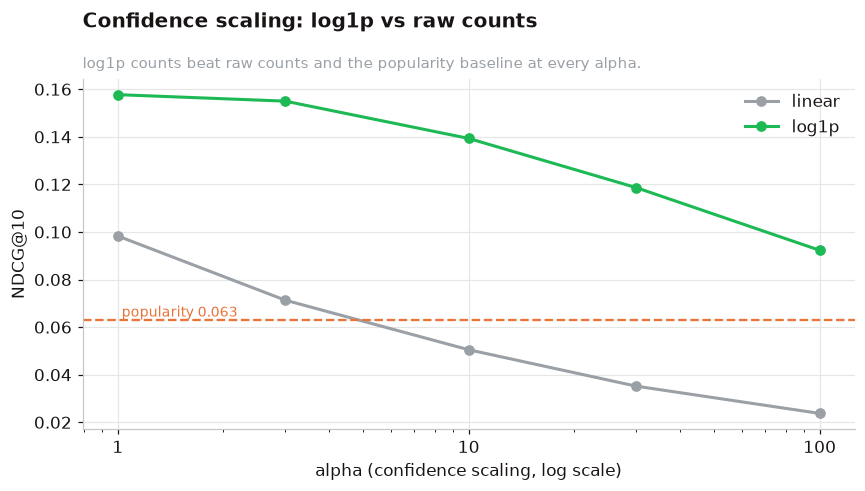

In [4]:
_ = viz.plot_alpha_curves(alphas, series, baseline=pop[f'ndcg@{K}'],
                          subtitle='log1p counts beat raw counts and the popularity baseline at every alpha.',
                          save_path=FIG / 'als_alpha_ablation.png')

**Finding.** Log-scaling counts wins decisively and is far less sensitive to `alpha`. With raw counts, a handful of mega-played artists (counts up to 352,698) dominate every user's confidence, and quality collapses as `alpha` grows. This is Hu et al.'s log-confidence variant; it is now a fixed modelling decision (`decisions.md`, 2026-06-30). The search in Milestone 4 tunes `alpha` *within* the log1p model.

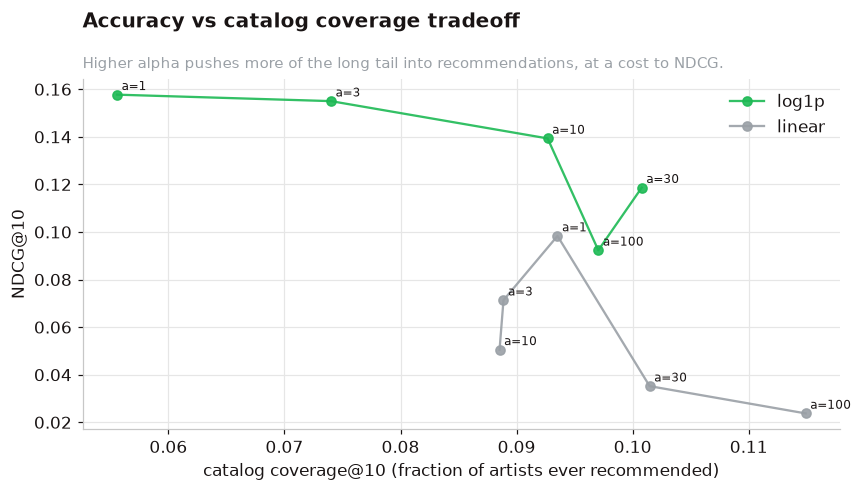

In [5]:
_ = viz.plot_accuracy_coverage(records, save_path=FIG / 'als_accuracy_coverage.png')

## Who does the model actually help? Looking past the average

A single NDCG number hides who is served well. Two questions: how is per-user accuracy *distributed*, and does the model favour users with **mainstream** taste (a user-level echo of the popularity bias)?

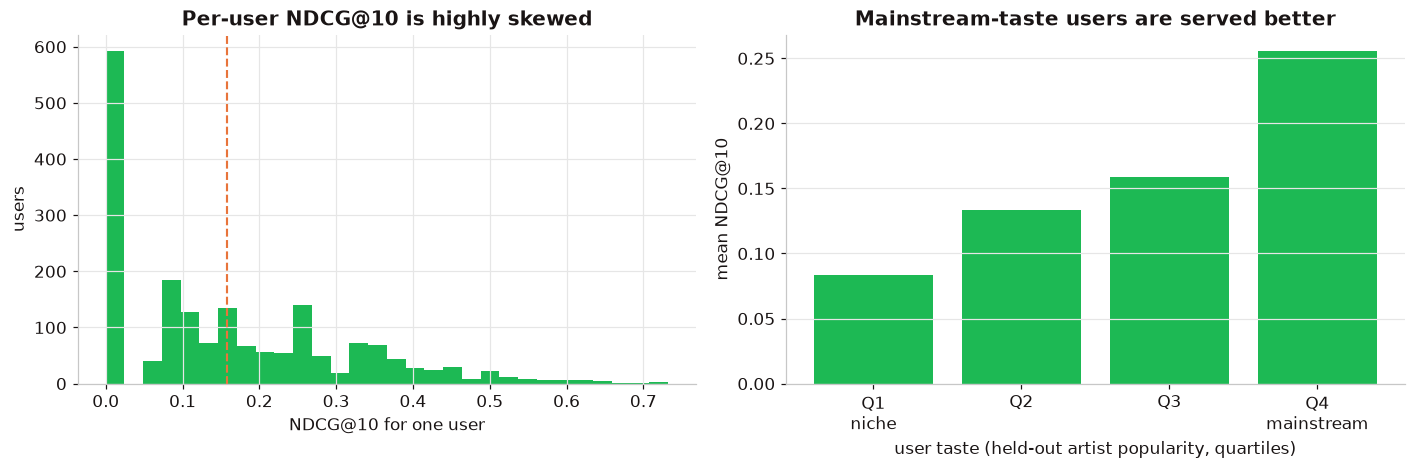

31% of users get NDCG@10 = 0 (no hit in top-10); median 0.109, mean 0.158
mean NDCG: niche quartile 0.083  vs  mainstream quartile 0.255 (3.1x)


In [6]:
import matplotlib.pyplot as plt

model_a1, conf_a1 = als_model.train_als(train, factors=64, regularization=0.01,
                                        iterations=15, alpha=1.0, seed=0)
recs_a1 = als_model.recommend_top_n(model_a1, conf_a1, scored, n=K)
ndcg_u = eval_core.per_user_scores(recs_a1, test, scored, K)[f'ndcg@{K}']

# "mainstreamness" of a user = mean listener-count of their held-out test artists
mainstream = np.array([listeners[test.getrow(int(u)).indices].mean() for u in scored])
groups = np.array_split(np.argsort(mainstream), 4)
labels = ['Q1\nniche', 'Q2', 'Q3', 'Q4\nmainstream']
group_ndcg = [ndcg_u[g].mean() for g in groups]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].hist(ndcg_u, bins=30, color=viz.GREEN)
ax[0].axvline(ndcg_u.mean(), color=viz.ACCENT, ls='--', lw=1.4)
ax[0].set(title='Per-user NDCG@10 is highly skewed', xlabel='NDCG@10 for one user', ylabel='users')
ax[1].bar(labels, group_ndcg, color=viz.GREEN)
ax[1].set(title='Mainstream-taste users are served better',
          xlabel='user taste (held-out artist popularity, quartiles)', ylabel='mean NDCG@10')
ax[1].grid(axis='x', visible=False)
fig.tight_layout(); fig.savefig(FIG / 'als_who_it_helps.png'); plt.show()

print(f"{(ndcg_u == 0).mean()*100:.0f}% of users get NDCG@10 = 0 (no hit in top-10); "
      f"median {np.median(ndcg_u):.3f}, mean {ndcg_u.mean():.3f}")
print(f"mean NDCG: niche quartile {group_ndcg[0]:.3f}  vs  mainstream quartile {group_ndcg[3]:.3f} "
      f"({group_ndcg[3]/max(group_ndcg[0],1e-9):.1f}x)")

The average is carried by a minority: a large share of users get **zero** hits in their top-10 (their held-out artists are too niche to retrieve), while users whose held-out taste is mainstream are served several times better. This is the popularity bias seen from the user side, and it's an equity consideration — niche-taste listeners are systematically under-served. It also bounds how far accuracy alone can go on this data.

There is a real **accuracy vs coverage** tradeoff: larger `alpha` surfaces more of the long-tail catalogue (higher coverage) but lowers NDCG. Which to prefer is a product question, not just a metric one — worth flagging in the model card.

## A qualitative look: recommendations for one user

Numbers aside, do the recommendations look sensible? Map item indices back to artist names and inspect one user's known artists vs their top recommendations (best log1p config).

In [7]:
import pandas as pd
item_index = pd.read_parquet(ITEM_INDEX_PATH).set_index('col')['artistID']
artist_name = dl.load_artists().set_index('id')['name']
def names(cols):
    return [artist_name.get(int(item_index.loc[int(c)]), f'artist {c}') for c in cols]

model, conf = als_model.train_als(train, factors=64, regularization=0.01,
                                  iterations=15, alpha=1.0, seed=0)
u = int(scored[0])
row = train.getrow(u)
top_known = row.indices[np.argsort(row.data)[::-1][:8]]
recs = als_model.recommend_top_n(model, conf, np.array([u]), n=K)[0]
print(f'user row {u} — top listened artists (train):')
for nm in names(top_known):
    print('   ', nm)
print('\ntop-10 recommended artists (ALS, log1p, alpha=1):')
for nm in names(recs):
    print('   ', nm)

user row 0 — top listened artists (train):
    Duran Duran
    Morcheeba
    Goldfrapp
    New Order
    Matt Bianco
    Talk Talk
    Prefab Sprout
    Enigma

top-10 recommended artists (ALS, log1p, alpha=1):
    Pet Shop Boys
    a-ha
    Orchestral Manoeuvres in the Dark
    The Human League
    Simple Minds
    Erasure
    Keane
    The Police
    Tears for Fears
    Ultravox


## Summary

- ALS with **log1p confidence** roughly doubles NDCG@10 over the popularity baseline; raw counts barely beat it and collapse at high `alpha`.
- The metric is stable across seeds (the runner logs mean +/- std; std ~0.002), confirming the lightweight seed check is sufficient here.
- Recommendations are qualitatively coherent (same-genre neighbours of a user's known artists).

The runner `python -m src.harness.run_search` logs one config to `outputs/experiments/log.jsonl`. Next: **Milestone 4** — run the pre-registered search in `program.md` over `alpha`/`factors`/`regularization`/`iterations`, pick a config with reasoning, and confirm once on the locked holdout.